# 요금제 EDA

`data/final/`의 최종 요금제·혜택 CSV를 한 번에 요약하지 않고, 한 항목씩 찍어보면서
다음 phase(페르소나 재정의 -> 합성 유저 데이터)에 쓸 근거를 쌓는다.

컬럼 의미는 `docs/컬럼_명세서.md`에 정리되어 있고, 특히 아래 두 가지를 주의한다.
- 가격 비교는 `monthly_fee`(정가)가 아니라 `discounted_fee`(실제 납부액)로 한다.
- `data_gb`가 비어 있으면 결측이 아니라 무제한이다(`data_unlimited`로 따로 본다).

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# notebooks/ 에서 실행돼도 src/schema.py를 import할 수 있게 경로를 잡는다.
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(BASE_DIR / "src"))
from schema import final_path  # noqa: E402

pd.set_option("display.max_columns", 50)
plans = pd.read_csv(final_path("통신요금제_통합데이터_최종.csv"), encoding="utf-8-sig")
benefits = pd.read_csv(final_path("통신요금제_혜택상세_최종.csv"), encoding="utf-8-sig")
plans.shape, benefits.shape

((2761, 39), (5408, 13))

In [2]:
plans.head(3)

,carrier_type,host_mno,mvno_brand,plan_id,base_plan_id,plan_id_type,plan_name,selected_option,plan_category,is_online_only,age_condition,network_gen,base_data_gb,extra_data_gb,data_gb,data_unlimited,data_throttle_speed,daily_data_gb,base_tethering_gb,extra_tethering_gb,tethering_gb,voice_unlimited,voice_minutes,voice_extra_minutes,sms_unlimited,sms_count,monthly_fee,discounted_fee,discount_type,discount_period_months,benefit_count,ott_option_count,ott_options,membership_grade,smart_device_benefit,extra_data_benefit,gift_benefit,source_url,crawled_at
0,MNO,KT,NaN,1692_초이스 더블 유튜브 프리미엄+넷플릭스_지니스마트음악감상,1692_초이스 더블 유튜브 프리미엄+넷플릭스,official_code,초이스 더블 유튜브 프리미엄+넷플릭스 (지니 스마트 음악감상),지니 스마트 음악감상,KT-통합요금제,False,NaN,5G,NaN,NaN,NaN,True,100Kbps,NaN,90.0,NaN,90.0,True,NaN,300.0,True,NaN,120000,90000.0,선택약정 25% 할인,NaN,7,3,지니뮤직 | 유튜브 프리미엄 | 넷플릭스,VVIP,스마트기기 또는 데이터 쉐어링 스마트 기기 월정액 / 데이터 쉐어링 월정액 각 1회...,공유데이터 90GB,NaN,https://product.kt.com/wDic/productDetail.do?I...,2026-08-03T02:47:43.791808+00:00
1,MNO,KT,NaN,1692_초이스 더블 유튜브 프리미엄+넷플릭스_밀리의서재,1692_초이스 더블 유튜브 프리미엄+넷플릭스,official_code,초이스 더블 유튜브 프리미엄+넷플릭스 (밀리의서재),밀리의서재,KT-통합요금제,False,NaN,5G,NaN,NaN,NaN,True,100Kbps,NaN,90.0,NaN,90.0,True,NaN,300.0,True,NaN,120000,90000.0,선택약정 25% 할인,NaN,7,3,밀리의서재 | 유튜브 프리미엄 | 넷플릭스,VVIP,스마트기기 또는 데이터 쉐어링 스마트 기기 월정액 / 데이터 쉐어링 월정액 각 1회...,공유데이터 90GB,NaN,https://product.kt.com/wDic/productDetail.do?I...,2026-08-03T02:47:43.791808+00:00
2,MNO,KT,NaN,1692_초이스 더블 유튜브 프리미엄+넷플릭스_쇼핑라운지할인쿠폰(5천원권),1692_초이스 더블 유튜브 프리미엄+넷플릭스,official_code,초이스 더블 유튜브 프리미엄+넷플릭스 (쇼핑라운지 할인 쿠폰 (5천원권)),쇼핑라운지 할인 쿠폰 (5천원권),KT-통합요금제,False,NaN,5G,NaN,NaN,NaN,True,100Kbps,NaN,90.0,NaN,90.0,True,NaN,300.0,True,NaN,120000,90000.0,선택약정 25% 할인,NaN,7,2,유튜브 프리미엄 | 넷플릭스,VVIP,스마트기기 또는 데이터 쉐어링 스마트 기기 월정액 / 데이터 쉐어링 월정액 각 1회...,공유데이터 90GB,쇼핑라운지 할인 쿠폰 (5천원권),https://product.kt.com/wDic/productDetail.do?I...,2026-08-03T02:47:43.791808+00:00


## 1. 통신사/유형 분포

In [3]:
plans["carrier_type"].value_counts()

carrier_type
MVNO    2207
MNO      554
Name: count, dtype: int64

In [4]:
plans["host_mno"].value_counts()

host_mno
KT      1046
LGU+    1026
SKT      689
Name: count, dtype: int64

In [5]:
# MVNO만 골라 브랜드 상위 15개 - 알뜰폰 시장이 특정 브랜드에 쏠려 있는지 본다
plans.loc[plans["carrier_type"] == "MVNO", "mvno_brand"].value_counts().head(15)

mvno_brand
티플러스        221
프리티         181
스마텔         173
아이즈모바일      170
이야기모바일      160
모빙          150
SK7모바일      121
KT스카이라이프     85
고고모바일        85
에이모바일        82
이지모바일        79
더원모바일        77
KG모바일        76
리브모바일        74
U+유모바일       62
Name: count, dtype: int64

In [6]:
plans["network_gen"].value_counts()

network_gen
LTE    1685
5G     1076
Name: count, dtype: int64

## 2. 가격 (`discounted_fee` = 실제 납부액, `monthly_fee`는 정가라 비교엔 안 씀)

In [7]:
plans["discounted_fee"].describe()

count     2715.000000
mean     25556.975691
std      24942.983715
min          0.000000
25%       8800.000000
50%      18000.000000
75%      33000.000000
max      97500.000000
Name: discounted_fee, dtype: float64

In [8]:
plans.groupby("carrier_type")["discounted_fee"].describe()

,count,mean,std,min,25%,50%,75%,max
carrier_type,,,,,,,,
MNO,508.0,65451.740157,26504.101779,8992.0,41250.0,71250.0,90000.0,97500.0
MVNO,2207.0,16374.130041,12373.335942,0.0,6900.0,14500.0,23000.0,65890.0


In [9]:
plans.groupby("host_mno")["discounted_fee"].describe()

,count,mean,std,min,25%,50%,75%,max
host_mno,,,,,,,,
KT,1046.0,34258.337476,28136.581547,0.0,14300.0,23000.0,44000.0,97500.0
LGU+,980.0,18494.583673,19492.550028,0.0,4830.0,13935.0,25137.5,97500.0
SKT,689.0,22392.272859,22692.079907,10.0,7990.0,15180.0,27500.0,96750.0


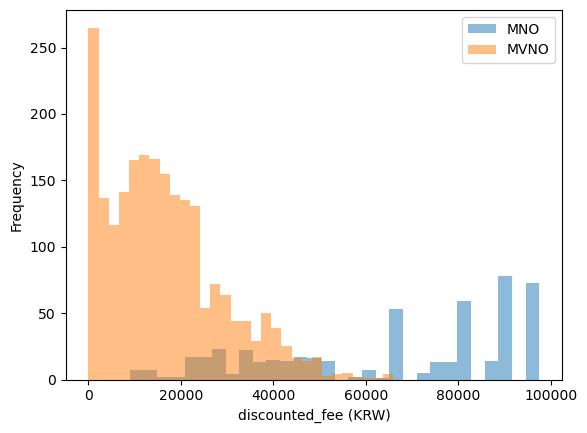

In [10]:
fig, ax = plt.subplots()
for carrier, group in plans.groupby("carrier_type"):
    group["discounted_fee"].dropna().plot(kind="hist", bins=30, alpha=0.5, ax=ax, label=carrier)
ax.set_xlabel("discounted_fee (KRW)")
ax.legend()
plt.show()

## 3. 데이터 제공량 (`data_gb`가 비면 결측이 아니라 무제한 -> `data_unlimited`로 따로 본다)

In [11]:
# carrier_type별 데이터 무제한 비율
plans.groupby("carrier_type")["data_unlimited"].mean()

carrier_type
MNO     0.638989
MVNO    0.000000
Name: data_unlimited, dtype: float64

In [12]:
# 무제한 제외(정량 요금제만) data_gb 분포
metered = plans.loc[~plans["data_unlimited"].fillna(False)]
metered.groupby("carrier_type")["data_gb"].describe()

,count,mean,std,min,25%,50%,75%,max
carrier_type,,,,,,,,
MNO,192.0,41.748698,57.855671,0.244,6.0,15.0,50.0,300.0
MVNO,2207.0,29.785662,43.773505,0.098,7.0,11.0,17.0,300.0


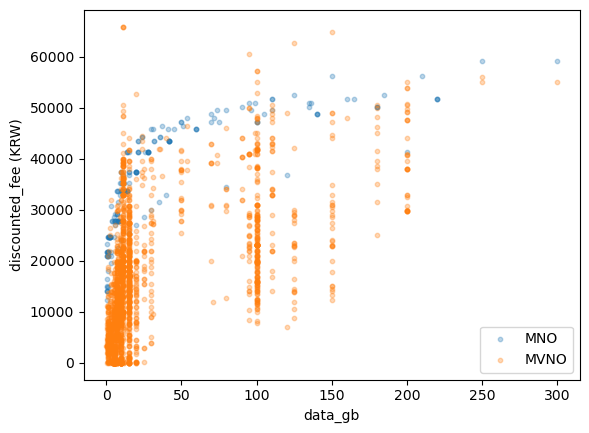

In [13]:
fig, ax = plt.subplots()
for carrier, group in metered.groupby("carrier_type"):
    ax.scatter(group["data_gb"], group["discounted_fee"], alpha=0.3, s=10, label=carrier)
ax.set_xlabel("data_gb")
ax.set_ylabel("discounted_fee (KRW)")
ax.legend()
plt.show()

## 4. 통화·문자 (대부분 무제한일 것으로 예상 - 실제로 얼마나인지 확인)

In [14]:
plans.groupby("carrier_type")[["voice_unlimited", "sms_unlimited"]].mean()

,voice_unlimited,sms_unlimited
carrier_type,,
MNO,0.954874,0.942238
MVNO,0.521976,0.504758


In [15]:
# 음성이 무제한이 아닌 요금제만 - 몇 분이나 주는지 (제한형 요금제의 실제 스펙)
plans.loc[~plans["voice_unlimited"].fillna(False), "voice_minutes"].describe()

count     944.000000
mean      301.385593
std       571.933750
min         2.000000
25%       100.000000
50%       200.000000
75%       300.000000
max      9997.000000
Name: voice_minutes, dtype: float64

## 5. 연령 조건 (`age_condition`, 정규화된 값 - schema.normalize_age_condition 적용 후)

In [16]:
# 일반(연령 무관) 요금제 비율
(plans["age_condition"].fillna("") == "").mean()

np.float64(0.8815646504889533)

In [17]:
plans.loc[plans["age_condition"].fillna("") != "", "age_condition"].value_counts()

age_condition
만 34세 이하    113
만 65세 이상     75
만 75세 이상     64
만 18세 이하     58
만 12세 이하     14
만 70세 이상      1
만 80세 이상      1
현역병사          1
Name: count, dtype: int64

In [18]:
# 연령 조건 요금제가 MNO/MVNO 어느 쪽에 몰려 있는지 - 페르소나의 연령x통신사 선호 조합이
# 실제로 가입 가능한 조합인지 확인하는 목적
restricted = plans.loc[plans["age_condition"].fillna("") != ""]
pd.crosstab(restricted["age_condition"], restricted["carrier_type"])

carrier_type,MNO
age_condition,
만 12세 이하,14
만 18세 이하,58
만 34세 이하,113
만 65세 이상,75
만 70세 이상,1
만 75세 이상,64
만 80세 이상,1
현역병사,1


## 6. 혜택 (요금제 테이블의 요약 컬럼 + benefits.csv 상세)

In [19]:
plans["ott_option_count"].value_counts().sort_index()

ott_option_count
0    2439
1     110
2      45
3      68
4      99
Name: count, dtype: int64

In [20]:
plans["membership_grade"].value_counts()

membership_grade
VVIP    186
VIP     156
Name: count, dtype: int64

In [21]:
benefits["benefit_category"].value_counts()

benefit_category
사은품/페이백    2532
OTT/구독      800
추가데이터       714
기타          600
스마트기기       420
멤버십         342
Name: count, dtype: int64

In [22]:
# benefit_value_won은 일부만 채워진다(컬럼 명세서 확인됨) - 채움 비율과
# 채워진 값의 분포를 분리해서 봐야 평균을 오독하지 않는다
print("채움 비율:", benefits["benefit_value_won"].notna().mean())
benefits["benefit_value_won"].dropna().describe()

채움 비율: 0.22725591715976332


count      1229.000000
mean      25714.410090
std       35940.900543
min           0.000000
25%        5000.000000
50%       15000.000000
75%       20000.000000
max      204000.000000
Name: benefit_value_won, dtype: float64

## 7. 요금제 개수 (행 수 vs 실제 요금제 수)

In [23]:
# 행 수(택1 전개 포함) vs 실제 요금제 수(base_plan_id 기준)
len(plans), plans["base_plan_id"].nunique()

(2761, 2363)

## 8. 결측/커버리지 종합 (39개 plan + 13개 benefit 컬럼 전체를 한 번에)

지금까지는 컬럼별로 필요할 때만 결측을 확인했다. 어떤 컬럼이 애초에 잘 안 채워지는지
전체를 한 번에 훑어서, 뒤 섹션에서 어느 컬럼을 믿고 어느 컬럼을 조심해야 할지 정한다.

In [24]:
import seaborn as sns

null_rate = pd.concat([
    plans.isna().mean().rename("plans"),
    benefits.isna().mean().rename("benefits"),
])
null_rate = null_rate.sort_values(ascending=False)
null_rate.head(20)

benefit_tier            0.985577
user_pay_won            0.985392
extra_data_gb           0.967765
extra_tethering_gb      0.947483
daily_data_gb           0.910902
selected_option         0.896052
ott_options             0.883376
age_condition           0.881565
membership_grade        0.876132
smart_device_benefit    0.875045
benefit_service         0.850777
select_group            0.830436
extra_data_benefit      0.821442
benefit_value_won       0.772744
voice_minutes           0.658095
sms_count               0.644694
tethering_gb            0.641796
base_tethering_gb       0.641796
gift_benefit            0.539660
voice_extra_minutes     0.510322
dtype: float64

C:\Users\NT551_11TH\AppData\Local\Temp\ipykernel_11260\3092254421.py:5: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NT551_11TH\AppData\Local\Temp\ipykernel_11260\3092254421.py:5: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NT551_11TH\AppData\Local\Temp\ipykernel_11260\3092254421.py:5: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NT551_11TH\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\NT551_11TH\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\NT551_11TH\anaconda3\Lib\site-packag

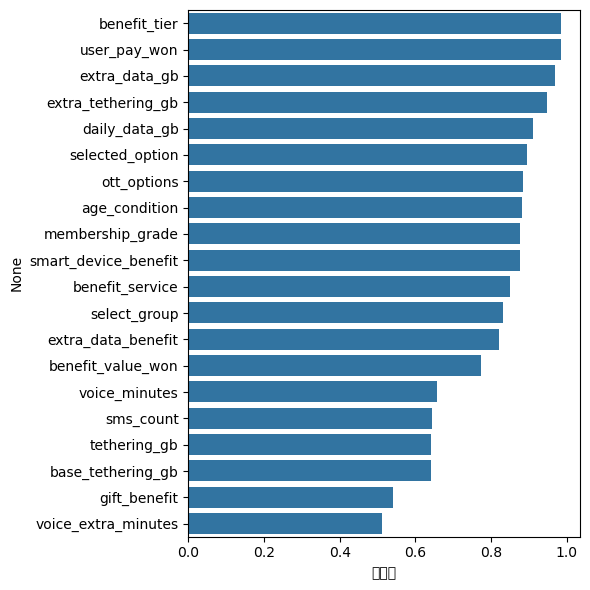

In [25]:
top_null = null_rate[null_rate > 0].head(20)
fig, ax = plt.subplots(figsize=(6, 6))
sns.barplot(x=top_null.values, y=top_null.index, ax=ax)
ax.set_xlabel("결측률")
plt.tight_layout()
plt.show()

## 9. MVNO 브랜드별 가격·데이터 (섹션1은 카운트만 봤음 - 브랜드마다 가격대가 다른지)

In [26]:
# 카운트 상위 10개 브랜드만 (롱테일 브랜드는 표본이 너무 작아 describe가 의미 없음)
top_brands = plans.loc[plans["carrier_type"] == "MVNO", "mvno_brand"].value_counts().head(10).index
mvno_top = plans[plans["mvno_brand"].isin(top_brands)]
mvno_top.groupby("mvno_brand")[["discounted_fee", "data_gb"]].describe()

discounted_fee                                               \
                    count          mean           std     min      25%   
mvno_brand                                                               
KT스카이라이프             85.0  25446.470588  12045.552895     0.0  17600.0   
SK7모바일              121.0  19581.900826  11952.134002  1900.0  10120.0   
고고모바일                85.0  18635.882353  11960.121764    10.0  11660.0   
모빙                  150.0  13807.933333  12191.041286    10.0   4400.0   
스마텔                 173.0  15029.017341  13630.722083    10.0   2530.0   
아이즈모바일              170.0  14466.176471  12468.955726    10.0   5267.5   
에이모바일                82.0  10449.146341   9974.845923    10.0    660.0   
이야기모바일              160.0  16993.343750  12460.141644     0.0   7700.0   
티플러스                221.0  12513.891403   8518.816780    10.0   5900.0   
프리티                 181.0  19004.917127  12860.121981    10.0  10670.0   

                                      data_gb                               \
                50%      75%      max   count       mean        std    min   
mvno_brand                                                                   
KT스카이라이프    24200.0  36300.0  49200.0    85.0  29.426400  42.043268  0.244   
SK7모바일      16900.0  26400.0  50600.0   121.0  18.289058  29.956250  0.488   
고고모바일       16000.0  24090.0  48730.0    85.0  26.517647  33.586283  1.000   
모빙          12000.0  18700.0  50000.0   150.0  28.856667  46.028709  1.000   
스마텔         13200.0  22000.0  53900.0   173.0  21.213873  34.686881  1.000   
아이즈모바일      12000.0  19000.0  57200.0   170.0  24.008824  34.025464  1.000   
에이모바일        8800.0  17687.5  39600.0    82.0  26.603659  39.998900  1.000   
이야기모바일      15050.0  23000.0  64900.0   160.0  25.603825  38.396513  0.488   
티플러스        11900.0  17600.0  30900.0   221.0  23.413122  31.983232  1.000   
프리티         17600.0  24200.0  65890.0   181.0  30.566851  42.526916  1.000   

                                      
              25%   50%   75%    max  
mvno_brand                            
KT스카이라이프     7.00  11.0  15.0  200.0  
SK7모바일       5.00  10.0  15.0  200.0  
고고모바일        7.00  11.0  15.0  110.0  
모빙           6.25  11.0  15.0  200.0  
스마텔          5.00  10.0  15.0  200.0  
아이즈모바일       7.00  11.0  15.0  150.0  
에이모바일        7.00  11.0  15.0  200.0  
이야기모바일       6.00  11.0  20.0  200.0  
티플러스         7.00  11.0  15.0  150.0  
프리티         10.00  11.0  20.0  200.0

C:\Users\NT551_11TH\AppData\Local\Temp\ipykernel_11260\1569432376.py:3: UserWarning: Glyph 54000 (\N{HANGUL SYLLABLE TI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NT551_11TH\AppData\Local\Temp\ipykernel_11260\1569432376.py:3: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NT551_11TH\AppData\Local\Temp\ipykernel_11260\1569432376.py:3: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NT551_11TH\AppData\Local\Temp\ipykernel_11260\1569432376.py:3: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NT551_11TH\AppData\Local\Temp\ipykernel_11260\1569432376.py:3: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NT551_11TH\AppData\Local\Temp\ipykernel_11260\1569432376.py:3: UserWarning: Glyph 47532 (\N{HANGUL SY

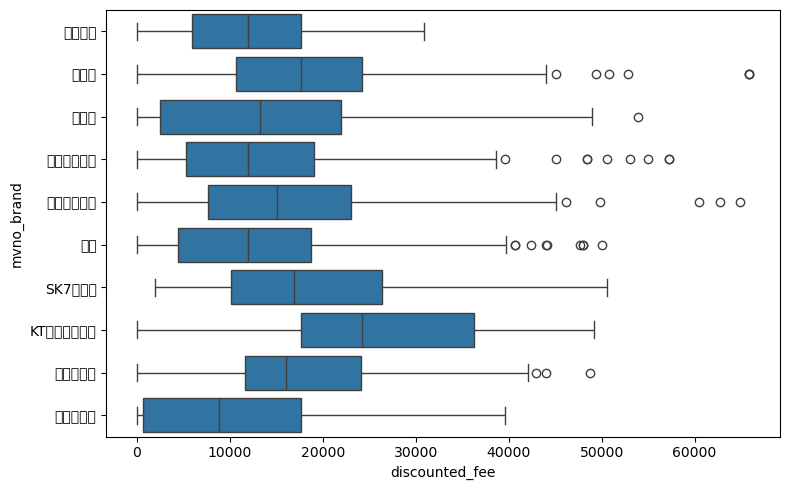

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=mvno_top, x="discounted_fee", y="mvno_brand", order=top_brands, ax=ax)
plt.tight_layout()
plt.show()

## 10. 5G/LTE 교차분석 (섹션1에서 카운트만 봤고 아무 것과도 교차 안 했음)

In [28]:
pd.crosstab(plans["network_gen"], plans["carrier_type"])

carrier_type,MNO,MVNO
network_gen,,
5G,545,531
LTE,9,1676


In [29]:
plans.groupby("network_gen")[["discounted_fee", "data_gb"]].describe()

discounted_fee                                             \
                     count          mean           std   min      25%   
network_gen                                                             
5G                  1031.0  42953.532493  31029.159590  10.0  16700.0   
LTE                 1684.0  14906.233373  10730.218268   0.0   6900.0   

                                       data_gb                               \
                 50%      75%      max   count       mean        std    min   
network_gen                                                                   
5G           36700.0  67500.0  97500.0   716.0  55.515784  62.712575  0.244   
LTE          14000.0  20900.0  65890.0  1683.0  20.204043  29.393759  0.098   

                                     
             25%   50%   75%    max  
network_gen                          
5G           9.0  20.0  95.0  300.0  
LTE          7.0  11.0  15.0  100.0

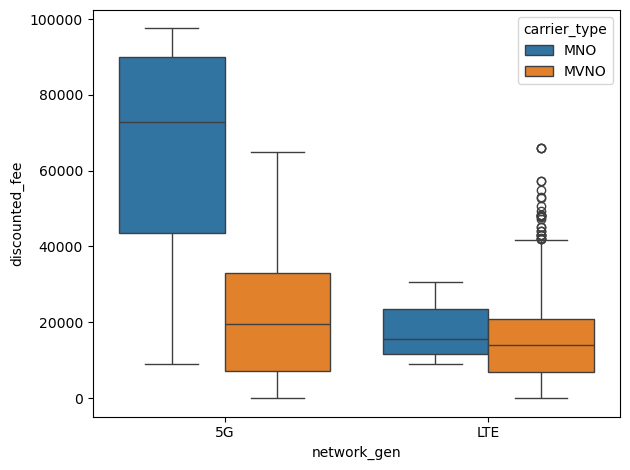

In [30]:
fig, ax = plt.subplots()
sns.boxplot(data=plans, x="network_gen", y="discounted_fee", hue="carrier_type", ax=ax)
plt.tight_layout()
plt.show()

## 11. 테더링 (`base_tethering_gb`/`extra_tethering_gb`/`tethering_gb` - 지금까지 미탐색)

In [31]:
teth_cols = ["base_tethering_gb", "extra_tethering_gb", "tethering_gb"]
plans[teth_cols].isna().mean(), plans[teth_cols].describe()

(base_tethering_gb     0.641796
 extra_tethering_gb    0.947483
 tethering_gb          0.641796
 dtype: float64,
        base_tethering_gb  extra_tethering_gb  tethering_gb
 count         989.000000          145.000000    989.000000
 mean           42.650152           59.034483     51.305359
 std            40.163775           28.298364     53.663011
 min             0.000000           20.000000      0.000000
 25%            10.000000           30.000000     10.000000
 50%            15.000000           60.000000     15.000000
 75%            80.000000           80.000000     90.000000
 max           140.000000          100.000000    200.000000)

In [32]:
# tethering_gb가 채워진 요금제만 - carrier_type/network_gen별로 얼마나 주는지
has_teth = plans.dropna(subset=["tethering_gb"])
pd.crosstab(has_teth["carrier_type"], has_teth["network_gen"])

network_gen,5G,LTE
carrier_type,,
MNO,400,3
MVNO,152,434


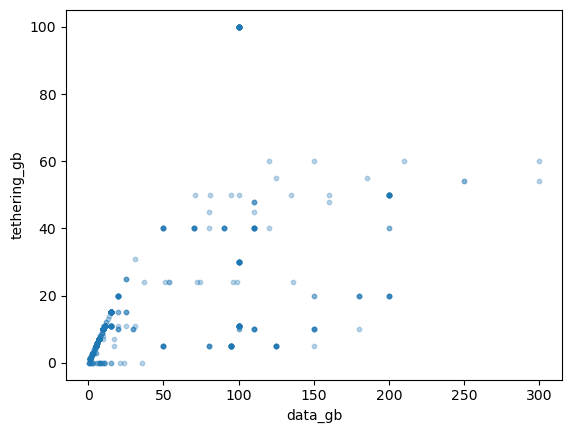

In [33]:
fig, ax = plt.subplots()
ax.scatter(has_teth["data_gb"], has_teth["tethering_gb"], alpha=0.3, s=10)
ax.set_xlabel("data_gb")
ax.set_ylabel("tethering_gb")
plt.show()

## 12. 데이터 소진 후 속도 (`data_throttle_speed` - 지금까지 미탐색)

In [34]:
plans["data_throttle_speed"].value_counts()

data_throttle_speed
1Mbps      728
3Mbps      528
5Mbps      309
100Kbps    164
400Kbps    111
200Kbps     48
10Mbps      38
Name: count, dtype: int64

In [35]:
# data_unlimited 요금제가 소진 후에도 완속으로 계속 되는 건지 - carrier_type과 교차
pd.crosstab(plans["carrier_type"], plans["data_throttle_speed"].notna(), rownames=["carrier_type"], colnames=["has_throttle_speed"])

has_throttle_speed,False,True
carrier_type,,
MNO,182,372
MVNO,653,1554


## 13. 요금 구조 (정가-할인가 갭, `discount_type`, `discount_period_months` - 지금까지 `discounted_fee`만 봤음)

In [36]:
# 정가 대비 실제 납부액이 얼마나 깎이는지 (할인율)
gap = (plans["monthly_fee"] - plans["discounted_fee"]) / plans["monthly_fee"]
gap.describe()

count    2715.000000
mean        0.371653
std         0.312138
min         0.000000
25%         0.000000
50%         0.280303
75%         0.606061
max         1.000000
dtype: float64

In [37]:
plans["discount_type"].value_counts()

discount_type
모요 프로모션 할인        1407
선택약정 25% 할인        508
모요 프로모션 페이백/할인      85
Name: count, dtype: int64

In [38]:
pd.crosstab(plans["discount_type"], plans["carrier_type"])

carrier_type,MNO,MVNO
discount_type,,
모요 프로모션 페이백/할인,0,85
모요 프로모션 할인,0,1407
선택약정 25% 할인,508,0


In [39]:
plans["discount_period_months"].describe()

count    1491.000000
mean       10.329980
std         6.705685
min         4.000000
25%         7.000000
50%         7.000000
75%        12.000000
max        36.000000
Name: discount_period_months, dtype: float64

## 14. 온라인전용/카테고리 (`is_online_only`, `plan_category` - 지금까지 미탐색)

In [40]:
plans.groupby("host_mno")["is_online_only"].mean()

host_mno
KT      0.707457
LGU+    0.912281
SKT     0.856313
Name: is_online_only, dtype: float64

In [41]:
plans["plan_category"].value_counts()

plan_category
moyo                2207
KT-통합요금제             301
LGU+-통합               60
SKT-베스트               58
LGU+-온라인가입전용(너겟)      46
SKT-라이트               26
SKT-전용                15
KT-온라인전용(요고)          13
LGU+-청년(유쓰)           11
KT-키즈/외국인              5
LGU+-키즈                5
LGU+-청소년               5
LGU+-시니어               5
LGU+-LTE               4
Name: count, dtype: int64

## 15. 혜택 심화 (섹션6은 카테고리·등급·value_won 채움비율만 봤음 - 서비스명·등급·실부담금·택1구조는 미탐색)

In [42]:
# 어느 서비스가 가장 많이 번들되는지 (OTT/구독 위주로 예상)
benefits["benefit_service"].value_counts().head(15)

benefit_service
밀리의서재        240
지니뮤직         168
구글 원          64
유튜브 프리미엄      58
넷플릭스          47
삼성 디바이스       47
디즈니+          46
티빙            37
폰케어           31
가전구독          15
위버스           15
Google AI     10
T 우주          10
데일리플러스         6
애플 디바이스        6
Name: count, dtype: int64

In [43]:
pd.crosstab(benefits["benefit_category"], benefits["benefit_tier"])

benefit_tier,Lite,광고형,광고형 스탠다드,베이직,스탠다드,프리미엄
benefit_category,,,,,,
OTT/구독,2,4,20,0,28,10
사은품/페이백,0,2,11,1,0,0


In [44]:
# user_pay_won(실부담금) vs benefit_value_won(정가 가치) - 둘 다 채워진 행만
both = benefits.dropna(subset=["user_pay_won", "benefit_value_won"])
print("둘 다 채워진 행:", len(both), "/", len(benefits))
(both["benefit_value_won"] - both["user_pay_won"]).describe()

둘 다 채워진 행: 79 / 5408


count       79.000000
mean     15483.037975
std      12048.069039
min          0.000000
25%       9290.000000
50%      13500.000000
75%      19400.000000
max      52900.000000
dtype: float64

In [45]:
# is_selectable(택1 구조) 비율과, 택1 그룹(select_group)마다 선택지가 몇 개씩인지
print("택1 항목 비율:", benefits["is_selectable"].mean())
benefits.dropna(subset=["select_group"]).groupby(["plan_id", "select_group"]).size().describe()

택1 항목 비율: 0.16956360946745563


count    435.000000
mean       2.108046
std        1.609249
min        1.000000
25%        1.000000
50%        1.000000
75%        4.000000
max        5.000000
dtype: float64

## 16. 이상치 점검 (지금까지 describe만 보고 넘어간 min/max가 실제로 이상한 값인지)

In [46]:
# discounted_fee == 0 (섹션2 min이 0이었음) - 진짜 무료 요금제인지 파싱 오류인지
free = plans.loc[plans["discounted_fee"] == 0]
print(len(free), "건")
free[["plan_id", "carrier_type", "host_mno", "monthly_fee", "data_gb"]].head(10)

11 건


,plan_id,carrier_type,host_mno,monthly_fee,data_gb
557,23450,MVNO,KT,16900,15.000
564,6830,MVNO,LGU+,15900,7.000
568,6804,MVNO,LGU+,1700,0.488
571,6801,MVNO,LGU+,2700,1.000
573,6790,MVNO,LGU+,28820,15.000
636,6803,MVNO,LGU+,3700,2.000
644,6789,MVNO,LGU+,18900,10.000
663,11964,MVNO,LGU+,16900,9.000
665,32400,MVNO,LGU+,18330,7.000
682,11741,MVNO,LGU+,12100,6.000


In [47]:
# voice_minutes max=9997 (섹션4) - 무제한 근처인데 voice_unlimited=False로 분류된 건 아닌지
suspect = plans.loc[(plans["voice_unlimited"].fillna(False) == False) & (plans["voice_minutes"] > 1000)]
print(len(suspect), "건")
suspect[["plan_id", "carrier_type", "voice_unlimited", "voice_minutes"]]

28 건


,plan_id,carrier_type,voice_unlimited,voice_minutes
663,11964,MVNO,False,3000.0
896,26280,MVNO,False,3000.0
918,30011,MVNO,False,3000.0
1277,31945,MVNO,False,9997.0
2082,35856,MVNO,False,9996.0
2534,35795,MVNO,False,2000.0
2552,29806,MVNO,False,2000.0
2566,29812,MVNO,False,2000.0
2571,29839,MVNO,False,2000.0
2573,29872,MVNO,False,2000.0


In [48]:
# data_gb IQR 기준 이상치 (정량 요금제만, 무제한 제외)
metered_gb = plans.loc[~plans["data_unlimited"].fillna(False), "data_gb"].dropna()
q1, q3 = metered_gb.quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = metered_gb[(metered_gb < lo) | (metered_gb > hi)]
print(f"IQR 범위 [{lo:.1f}, {hi:.1f}], 이상치 {len(outliers)}건")
outliers.sort_values(ascending=False).head(10)

IQR 범위 [-12.5, 39.5], 이상치 480건


378     300.0
2438    300.0
377     250.0
2432    250.0
2446    250.0
215     220.0
228     220.0
256     220.0
429     210.0
2144    200.0
Name: data_gb, dtype: float64

## 17. 상관관계 (수치형 스펙 컬럼끼리 - 지금까지는 두 변수씩만 따로 봤음)

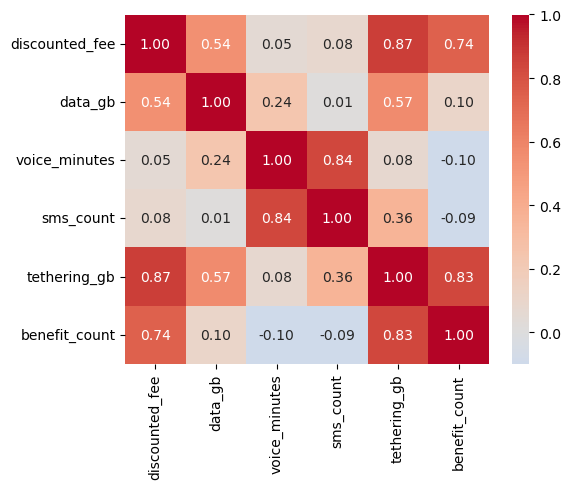

In [49]:
numeric_cols = ["discounted_fee", "data_gb", "voice_minutes", "sms_count", "tethering_gb", "benefit_count"]
corr = plans[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
plt.tight_layout()
plt.show()

## 정리 (섹션 8~17 실행 결과)

- **5G/LTE 가격·데이터 차이가 큼**: 5G 평균 42,953원(데이터 평균 55.5GB) vs LTE 평균
  14,906원(20.2GB) — carrier_type만큼이나 network_gen도 가격을 크게 가른다.
  향후 Plan Matching 스코어링에서 `preferred_network_gen`을 필터/가점으로 쓸 근거.
- **테더링 결측이 큼**: `base_tethering_gb`/`tethering_gb` 64%, `extra_tethering_gb`
  95% 결측 — 대부분 요금제가 테더링 정보를 안 주거나 해당 없음. User Profiling이
  테더링을 필수 슬롯으로 요구하면 안 됨(응답 못 하는 요금제가 대다수).
- **혜택 실부담금(`user_pay_won`)은 98.5% 결측**, `benefit_value_won`과 둘 다 채워진
  건 79/5408건뿐. "혜택 가치"로 스코어링하려면 `benefit_value_won`(채움률 25.5%,
  섹션6)에 의존할 수밖에 없고, 실부담금 기반 비교는 사실상 불가능.
- **이상치/데이터 품질 이슈 2건 발견**:
  - `voice_minutes`가 2000~9997분인데 `voice_unlimited=False`로 분류된 행 28건 —
    사실상 무제한에 가까운데 라벨이 다름. 원본 문구가 "사실상 무제한"류 표현일
    가능성이 높아 `docs/수정이력.md`에 기록 후보.
  - `discounted_fee == 0`인 요금제 11건 — 대부분 LGU+ MVNO 초저가 요금제
    (`monthly_fee` 1,700~28,820원대)라 파싱 오류보다는 실제 프로모션가로 보임.
  - `data_gb` IQR 기준 이상치 480건은 분포 자체가 오른쪽으로 크게 치우쳐서(대부분
    소용량, 소수 대용량) 나온 통계적 결과일 뿐 — 실제 파싱 오류로 보이진 않음.
- MVNO 상위 10개 브랜드 간 `discounted_fee` 평균이 브랜드마다 다르게 갈림(섹션9
  boxplot) — "알뜰폰은 다 저렴하다"가 아니라 브랜드별 가격 포지셔닝이 존재.

기존 섹션1~7의 두 사실(MVNO 무제한 비율 ~50%, 연령조건부=전량 MNO)이
`docs/세그먼트_설계.md` 근거로 쓰인 것처럼, 위 사실들도 다음 단계
(Plan Matching 스코어링 가중치, User Profiling 슬롯 설계)에 참고한다.